# Lab: Video Understanding & 3D Data

**Course:** Deep Learning: Advanced Models and Methods

**Instructor:** Antonino Furnari

**Duration:** 2 Hours (In-class Group Lab)

## 📝 Lab Format & Deliverables
* **Format:**
  * Students work in groups of 1-3.
  * The teacher gives a brief introduction to the lab, then students work independently with support from the teacher.
* **Strategy:**
  * Fill in the ☑️ `TODO` blocks. Do not modify the provided boilerplate unless necessary.
  * Check that you obtained reasonable results through the 🛑 `Checkpoints`.
  * Fill in the short 📝 `Reflections` where required.
  * Reach 🏁 `Milestones`.
* **Submission:**
  * Fill in this notebook and send it to <antonino.furnari@unict.it> as an `.ipynb` by the end of the lab.
* **Grading:**
  * Notebooks will be graded in binary way as passed / not passed based on completion (did the group reach all milestones successfully? are reflections adequate?)
  * Each notebook is worth $0.5$ bonus points. These are assigned to students individually (not to groups).
* **Computation:**
  * Run this notebook on Google Colab or Kaggle with GPU acceleration.

You will find the following blocks throughout the notebook:

> ☑️ **TODO**
>
> This box provides you instruction on a TODO that should be completed in the code cells below.

> 🛑 **Checkpoint**
>
> The following cells provide you instruction on what you should observe if you run a given cell after having implemented your TODOs. This serve as a self-check to assess potential bugs or errors early.

> 📝 **Reflection**
>
> You are required to write a short reflection on your results.

> 🏁 **Milestone**
>
> This signal that you completed a significant part of the notebook and reached a milestone.

## Your Data
> 📝 **Date and Team Composition**
>
> <i>Insert the current date, plus names, surnames, matricola, and emails of the team members below:</i>
>
> **Date:** YYYY-MM-DD
>
> **Link to wandb:** <a href="example_link">link</a>
>
> | Name | Surname | Matricola | Email |
> |---|---:|---:|---|
> | Name 1 | Surname1 | 0000001 | <a href="mailto:member1@example.com">member1@example.com</a> |
> | Name 2 | Surname2 | 0000002 | <a href="mailto:member2@example.com">member2@example.com</a> |
> | Name 3 | Surname3 | 0000003 | <a href="mailto:member3@example.com">member3@example.com</a> |

### 🎯 Learning Goals & Problem Setup
In this lab, you will explore the progression of video understanding from treating videos as bags-of-images to 3D CNNs and transformers.

We will consider the problem of video classification, where the input is a video and the output is a class out of a given taxonomy.

We will focus on handling videos as **5D Video Tensors**: $V \in \mathbb{R}^{B \times C \times T \times H \times W}$.

We will implement and compare three fundamental paradigms:
1. **Part 1 – 2D CNN:** Treating video as independent frames and using late fusion as a form of temporal pooling.
2. **Part 2 – 3D CNN:** Processing space and time jointly using volumetric convolutions, a natural extension of 2D CNNs to spatio-temporal inputs.
3. **Part 3 – Transformers:** Tokenizing videos into spatio-temporal "Tubelet" patches and utilizing self-attention, mimicking state-of-the-art models like TimeSformer and VideoMAE.

### Dataset - MiniUCF
For our experiments, we will use a simplified version of UCF101, a standard dataset for action classification.

<img src="https://www.crcv.ucf.edu/data/UCF101/UCF101.jpg">

The original data contains videos divided into 101 classes, but we will use only 10 of them to keep the laboratory manageable.

You can find more info on the original dataset here: https://www.crcv.ucf.edu/data/UCF101.php

## Preparation

Install necessary packages, load plotting utilities, and log in to Weights & Biases.
*Note: We install `av` to allow PyTorch to decode video files efficiently, and `gdown` to fetch our dataset.*

In [10]:
import os
import glob
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import torchvision.io as io
import torchvision.transforms as T
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import Callback
import torchmetrics
import wandb
import pandas as pd

# Configuration
BATCH_SIZE = 16
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
FRAMES = 16
IMG_SIZE = 64

# Set global seed for reproducibility
pl.seed_everything(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Setup complete. Using device: {device}")

# Weights & Biases Login
WANDB_PROJECT = "dl-lab-video-understanding"
print("\n🚀 Logging in to Weights & Biases...")
try:
    wandb.login()
    print(f"✅ Login successful! Runs will be logged to project: '{WANDB_PROJECT}'")
except Exception as e:
    print(f"⚠️ Login failed: {e}")
    print("⚠️ Switching to OFFLINE mode. Metrics will be saved locally.")
    os.environ["WANDB_MODE"] = "offline"

# ==========================================
# 📊 VISUALIZATION & METRICS UTILITIES
# ==========================================

class MetricHistoryCallback(pl.Callback):
    def __init__(self):
        super().__init__()
        self.history = {}

    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        for k, v in metrics.items():
            if k not in self.history: self.history[k] = []
            val = v.item() if isinstance(v, torch.Tensor) else v
            self.history[k].append(val)

    # Add on_exception hook to prevent AttributeError
    def on_exception(self, trainer, pl_module, exception):
        print(f"⚠️ MetricHistoryCallback caught an exception during training: {type(exception).__name__}: {exception}")
        pass

def plot_training_curves(history, title="Training Curves", smoothing_window=5):
    if not history:
        print("No metrics to plot.")
        return

    # Assuming all recorded metrics have the same length (epochs)
    epochs = range(1, len(next(iter(history.values()))) + 1)
    plt.figure(figsize=(14, 6))

    # --- Plot 1: Losses ---
    plt.subplot(1, 2, 1)
    for k, v in history.items():
        if 'loss' in k and 'epoch' not in k:
            # 1. Plot raw data (transparent)
            p = plt.plot(epochs, v, alpha=0.3, label=f'Raw {k}')
            color = p[0].get_color() # Grab color to match smoothed line

            # 2. Plot smoothed data (solid)
            if len(v) >= smoothing_window:
                smoothed_v = pd.Series(v).rolling(window=smoothing_window, min_periods=1).mean()
                plt.plot(epochs, smoothed_v, color=color, linewidth=2, label=f'Smoothed {k} (w={smoothing_window})')
            else:
                # Fallback if there aren't enough epochs for the window yet
                plt.plot(epochs, v, color=color, linewidth=2, label=f'{k}')

    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # --- Plot 2: Accuracies ---
    plt.subplot(1, 2, 2)
    has_acc = False
    for k, v in history.items():
        if 'acc' in k:
            has_acc = True

            # 1. Plot raw data (transparent)
            p = plt.plot(epochs, v, alpha=0.3, label=f'Raw {k}')
            color = p[0].get_color()

            # 2. Plot smoothed data (solid)
            if len(v) >= smoothing_window:
                smoothed_v = pd.Series(v).rolling(window=smoothing_window, min_periods=1).mean()
                plt.plot(epochs, smoothed_v, color=color, linewidth=2, label=f'Smoothed {k} (w={smoothing_window})')
            else:
                plt.plot(epochs, v, color=color, linewidth=2, label=f'{k}')

    if has_acc:
        plt.title(f'{title} - Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.grid(True, alpha=0.3)
        plt.legend()

    plt.tight_layout()
    plt.show()

INFO:lightning_fabric.utilities.seed:Seed set to 42
wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


✅ Setup complete. Using device: cuda

🚀 Logging in to Weights & Biases...
✅ Login successful! Runs will be logged to project: 'dl-lab-video-understanding'


## Preparation: The 5D Tensor Reality & Real Video Decoding

Real video datasets require decoding compressed files (`.mp4`, `.avi`), uniformly sampling frames across time, and transforming them into a 5D tensor.

To ensure our lab runs at a reasonable speed, we will download a "Mini UCF" subset from Google Drive, decode all the videos upfront, and load them directly into the GPU's VRAM as a single massive tensor.

Please mind that this will take ~5 minutes, so be patient and run the code below only once.



In [14]:
# 1. Download Mini UCF from Google Drive
GDRIVE_ID = "1BUmmh9hzPwkms9oMmzwbw-Q0DrWPXakZ"
zip_path = "miniucf.zip"
extract_dir = "miniucf_data"

if not os.path.exists(extract_dir):
    print("⏳ Downloading Mini UCF dataset from Google Drive...")
    os.system(f"gdown --id {GDRIVE_ID} -O {zip_path}")
    print("⏳ Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    os.remove(zip_path)

# Smart locate: find the actual folder containing class directories
data_dir = extract_dir
subdirs = [os.path.join(extract_dir, d) for d in os.listdir(extract_dir) if os.path.isdir(os.path.join(extract_dir, d))]
if len(subdirs) == 1:
    data_dir = subdirs[0]

# 2. In-Memory DataModule
class InMemoryUCFDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size=BATCH_SIZE, num_frames=FRAMES):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_frames = num_frames

        self.transform = T.Resize((IMG_SIZE, IMG_SIZE), antialias=True)
        self.classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.num_classes = len(self.classes)
        self.setup_done = False

        # We will store one representative video per class for visualization
        self.rep_videos = {}

        # Initialize these as instance attributes to ensure they always exist
        self.X_all = None
        self.y_all = None
        self.train_ds = None
        self.val_ds = None

    def setup(self, stage=None):
        if not self.setup_done:
            self.setup_done = True
            print("⏳ Decoding videos and loading directly into GPU VRAM (this takes a minute)...")
            X_list, y_list = [], []

            for cls_name in self.classes:
                cls_dir = os.path.join(self.data_dir, cls_name)
                for ext in ("*.avi", "*.mp4"):
                    for vid_path in glob.glob(os.path.join(cls_dir, ext)):
                        try:
                            vframes, _, _ = io.read_video(vid_path, pts_unit='sec', output_format="TCHW")
                            if vframes.shape[0] == 0: continue

                            indices = np.linspace(0, vframes.shape[0] - 1, self.num_frames, dtype=int)
                            vframes = vframes[indices].float() / 255.0
                            vframes = self.transform(vframes).permute(1, 0, 2, 3) # (C, T, H, W)

                            X_list.append(vframes)
                            y_list.append(self.class_to_idx[cls_name])

                            if cls_name not in self.rep_videos:
                                self.rep_videos[cls_name] = vframes.cpu()
                        except Exception:
                            pass

            self.X_all = torch.stack(X_list).to(device)
            self.y_all = torch.tensor(y_list).to(device)

            # Dataset Statistics
            print("\n📊 Dataset Statistics:")
            print(f"   Total Classes: {self.num_classes} ({self.classes})")
            print(f"   Total Videos:  {len(self.X_all)}")
            print(f"   Tensor Shape:  {self.X_all.shape} -> (Batch, Channels, Time, Height, Width)")

            full_dataset = TensorDataset(self.X_all, self.y_all)
            train_size = int(0.8 * len(full_dataset))
            val_size = len(full_dataset) - train_size
            self.train_ds, self.val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size)

dm = InMemoryUCFDataModule(data_dir)
dm.setup()
NUM_CLASSES = dm.num_classes

⏳ Decoding videos and loading directly into GPU VRAM (this takes a minute)...


/usr/local/lib/python3.12/dist-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from v


📊 Dataset Statistics:
   Total Classes: 10 (['BoxingPunchingBag', 'CricketShot', 'Drumming', 'HorseRiding', 'PlayingCello', 'PlayingDhol', 'PlayingGuitar', 'Punch', 'ShavingBeard', 'TennisSwing'])
   Total Videos:  1630
   Tensor Shape:  torch.Size([1630, 3, 16, 64, 64]) -> (Batch, Channels, Time, Height, Width)


> 📝 **Reflection 1**
>
> <i>While the code above runs, read the code and summarize in your own words what the cell is actually doing.</i>
>
> Your answer

### 👁️ Visualizing the Video Data
Let's verify our data processing by playing back one sample clip for each class!
We will use Matplotlib to render the 5D tensor back into a grid of HTML5 videos.

In [15]:
def plot_class_videos(rep_videos):
    """Renders one video per class as an HTML5 animation grid."""
    print("🎬 Generating video previews...")
    num_classes = len(rep_videos)
    fig, axes = plt.subplots(1, num_classes, figsize=(3 * num_classes, 3))

    if num_classes == 1: axes = [axes]

    images = []
    for ax, (cls_name, vid_tensor) in zip(axes, rep_videos.items()):
        ax.set_title(cls_name, fontsize=12, fontweight='bold')
        ax.axis('off')

        # Convert (C, T, H, W) to (T, H, W, C)
        vid_np = vid_tensor.permute(1, 2, 3, 0).numpy()
        vid_np = np.clip(vid_np, 0, 1)
        im = ax.imshow(vid_np[0])
        images.append((im, vid_np))

    def update(frame_idx):
        drawn_artists = []
        for im, vid_np in images:
            im.set_array(vid_np[frame_idx])
            drawn_artists.append(im)
        return drawn_artists

    anim = FuncAnimation(fig, update, frames=FRAMES, interval=100, blit=True)
    plt.close()
    return HTML(anim.to_html5_video())

# Display the videos!
plot_class_videos(dm.rep_videos)

🎬 Generating video previews...


> 🛑 **Checkpoint 1**
>
> Did the videos play above? Notice how temporal sampling captures the entire motion from start to finish.

> 📝 **Reflection 2**
>
> <i>Comment on the videos shown above. Is it easy to discriminate between the videos?</i>
>
> Your answer

### Training Boilerplate
To avoid repeating code, we will define our PyTorch Lightning `LightningModule` that we will reuse for all the models we build today.

In [16]:
class VideoClassificationTask(pl.LightningModule):
    def __init__(self, model, model_name):
        super().__init__()
        self.model = model
        self.model_name = model_name
        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = self.accuracy(logits, y)

        self.log(f'{self.model_name}/train_loss', loss, on_epoch=True, prog_bar=True)
        self.log(f'{self.model_name}/train_acc', acc, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        acc = self.accuracy(logits, y)
        self.log(f'{self.model_name}/val_acc', acc, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=LEARNING_RATE)

### Part 1: 2D CNN + Late Fusion

Our first baseline treats video as a collection of independent images. We will pass each frame through a 2D CNN, and then average the predictions over time.

To ensure a "Fair Fight", we are using a **Tiny 2D CNN** that has the exact same layer depth and parameter count as the 3D CNN we will build in Part 2.

> ☑️ **TODO 1: Reshape 5D to 4D**
>
> A standard 2D CNN cannot accept `(B, C, T, H, W)`. You must fold the `Time` dimension into the `Batch` dimension to create `(B*T, C, H, W)`.

In [17]:
class Tiny2DCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten()
        )
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        B, C, T, H, W = x.shape

        # <YOUR CODE HERE>
        # 1. Reshape x from (B, C, T, H, W) to (B*T, C, H, W)
        
        # </YOUR CODE HERE>

        # 2. Extract 2D features -> output shape: (B*T, 32)
        out = self.net(x_reshaped)

        # <YOUR CODE HERE>
        # 3. Reshape back to (B, T, 32)
        

        # 4. Temporal Average Pooling: Average across the Time dimension (dim=1)
        # Final shape should be (B, 32)
        
        # </YOUR CODE HERE>

        return self.fc(out)

# Sanity check
model_2d = Tiny2DCNN().to(device)
dummy_batch = torch.randn(BATCH_SIZE, 3, FRAMES, IMG_SIZE, IMG_SIZE).to(device)
dummy_out = model_2d(dummy_batch)
print(f"2D Model Output Shape: {dummy_out.shape} (Expected: {BATCH_SIZE}, {NUM_CLASSES})")

2D Model Output Shape: torch.Size([16, 10]) (Expected: 16, 10)


### 1.1 Training the 2D Baseline
Now we train our 2D CNN with Late Fusion.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loggers/wandb.py:400: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


🚀 Training Tiny 2D CNN Baseline...


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ Tiny2DCNN          │  5.5 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 5.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


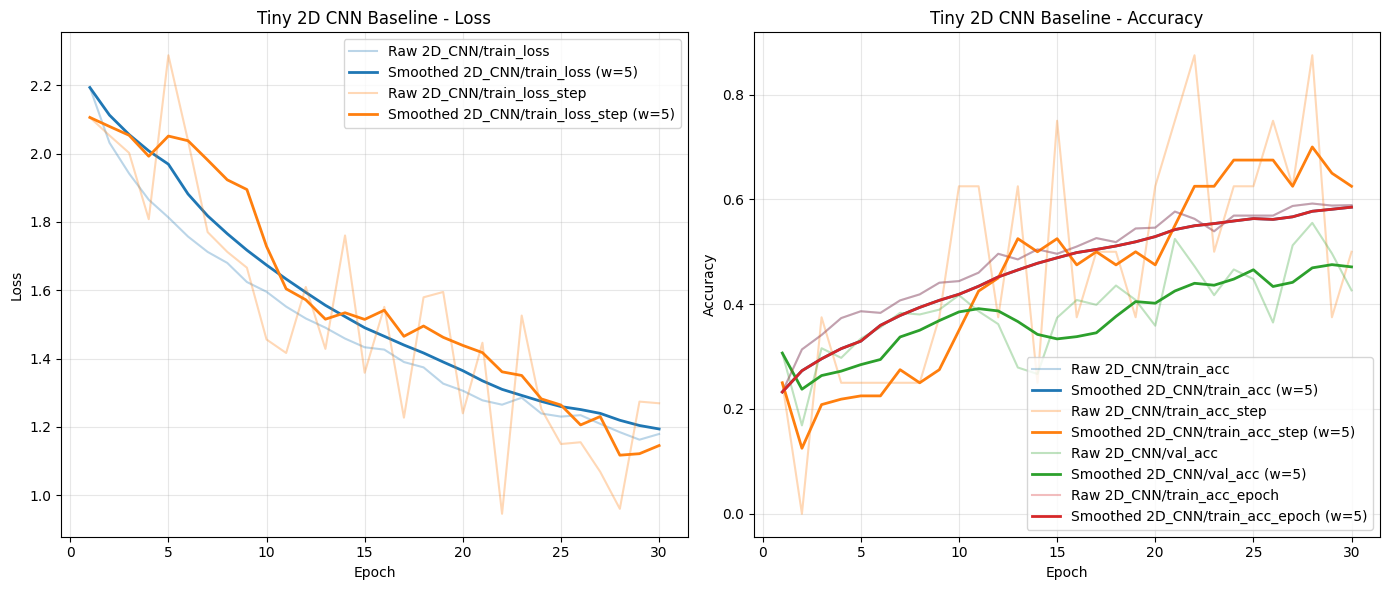

2D_CNN/train_acc_epoch,▁▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇█▇▇███████
2D_CNN/train_acc_step,▂▁▂▅▄▄▄▃▄▅▅▃▇▃▅▇▂▇▇▄▆▅▅▄▆▆▅▅▇▅▄▅▅▆▅█▃▆▇▆
2D_CNN/train_loss_epoch,█▇▆▆▅▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
2D_CNN/train_loss_step,█▇▇▇▅▆▅▆▅▅▅▃▅▄▆▃▃▆▂▃▄▂▃▃▅▃▃▂▂▂▂▂▁▃▂▃▁▆▂▃
2D_CNN/val_acc,▄▁▄▃▄▄▅▅▅▆▅▅▃▃▅▅▅▆▅▄▇▇▆▆▆▅▇█▇▆
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██
trainer/global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇█
2D_CNN/train_acc_epoch,0.58896
2D_CNN/train_acc_step,0.625
2D_CNN/train_loss_epoch,1.17952
2D_CNN/train_loss_step,0.96506


In [18]:
print("🚀 Training Tiny 2D CNN Baseline...")
task_2d = VideoClassificationTask(model_2d, "2D_CNN")
history_2d = MetricHistoryCallback()

trainer_2d = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator="auto",
    logger=WandbLogger(project=WANDB_PROJECT, name="2D_CNN"),
    callbacks=[history_2d],
    enable_checkpointing=False
)
trainer_2d.fit(task_2d, dm)

plot_training_curves(history_2d.history, title="Tiny 2D CNN Baseline")
wandb.finish()

Let's visualize the confusion matrix to see where the model is making most mistakes:

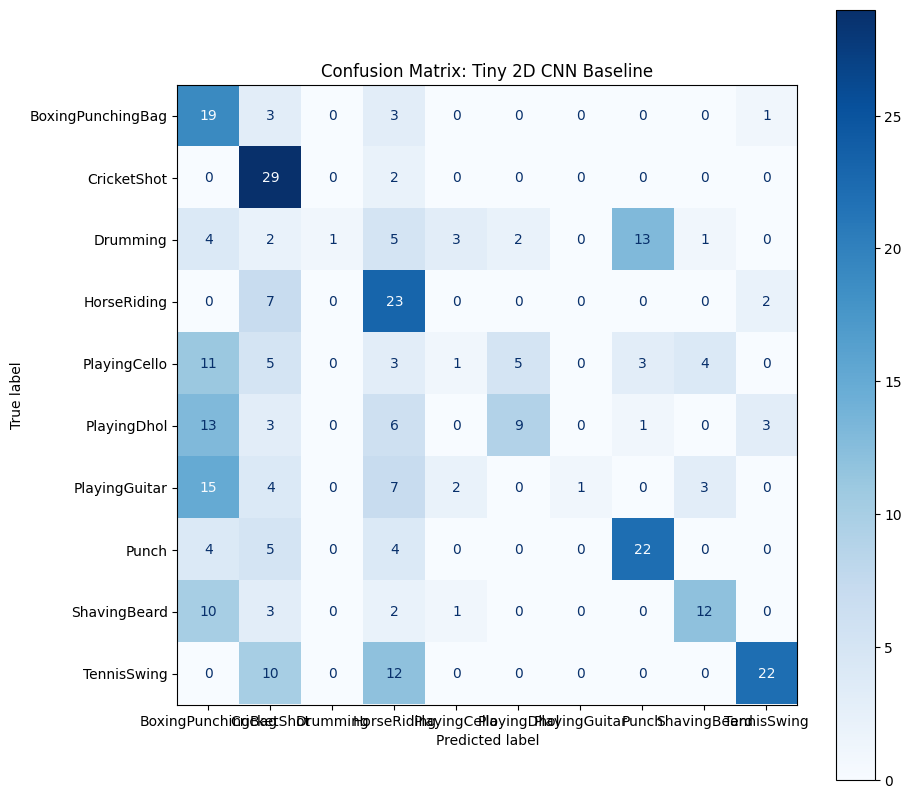

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_and_plot_confusion_matrix(model_task, datamodule, title):
    model_task.eval()
    model_task.to(device) # Ensure the model is on the correct device for evaluation
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in datamodule.val_dataloader():
            x, y = batch
            # x, y are already on 'device' from InMemoryUCFDataModule
            logits = model_task(x)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=datamodule.classes)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(title)
    plt.show()

# Evaluate and plot for 2D CNN
evaluate_and_plot_confusion_matrix(task_2d, dm, "Confusion Matrix: Tiny 2D CNN Baseline")

> 📝 **Reflection 3**
>
> <i>Comment on the performance obtained by this 2D CNN (accuracy and confusion matrix). Is it satisfactory? What are its shortcomings?</i>
>
> Your answer

### Part 2: 3D CNN

To capture temporal dynamics and motion, we can use 3D convolutions. A 3D kernel has the shape `(time_depth, height, width)`.



> ☑️ **TODO 2: Implement a Custom 3D CNN Block**
>
> Use `nn.Conv3d`, `nn.BatchNorm3d`, and `nn.MaxPool3d`.

In [22]:
from torch import nn

class Video3DCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        # <YOUR CODE HERE>
        # Define a 3D Conv block (call it self.block1)
        # Conv3d (in=3, out=16, kernel=3, padding=1)
        # BatchNorm3d
        # ReLU
        # MaxPool3d (kernel=(2,2,2)) -> This halves T, H, and W!
        
        # </YOUR CODE HERE>

        # <YOUR CODE HERE>
        # Define self.block2 including
        # Conv3D (16 -> 32)
        # BatchNorm3d
        # ReLU
        # Global average pooling over T, H, W
        
        # </YOUR CODE HERE>

        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        # x shape: (B, C, T, H, W)
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1) # Flatten
        return self.fc(x)

# Sanity check
model_3d = Video3DCNN().to(device)
dummy_out = model_3d(dummy_batch)
print(f"3D Model Output Shape: {dummy_out.shape} (Expected: {BATCH_SIZE}, {NUM_CLASSES})")

3D Model Output Shape: torch.Size([16, 10]) (Expected: 16, 10)


### 2.1 Training the 3D CNN
Let's train the 3D architecture:

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



🚀 Training 3D CNN...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ Video3DCNN         │ 15.6 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 15.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 15.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


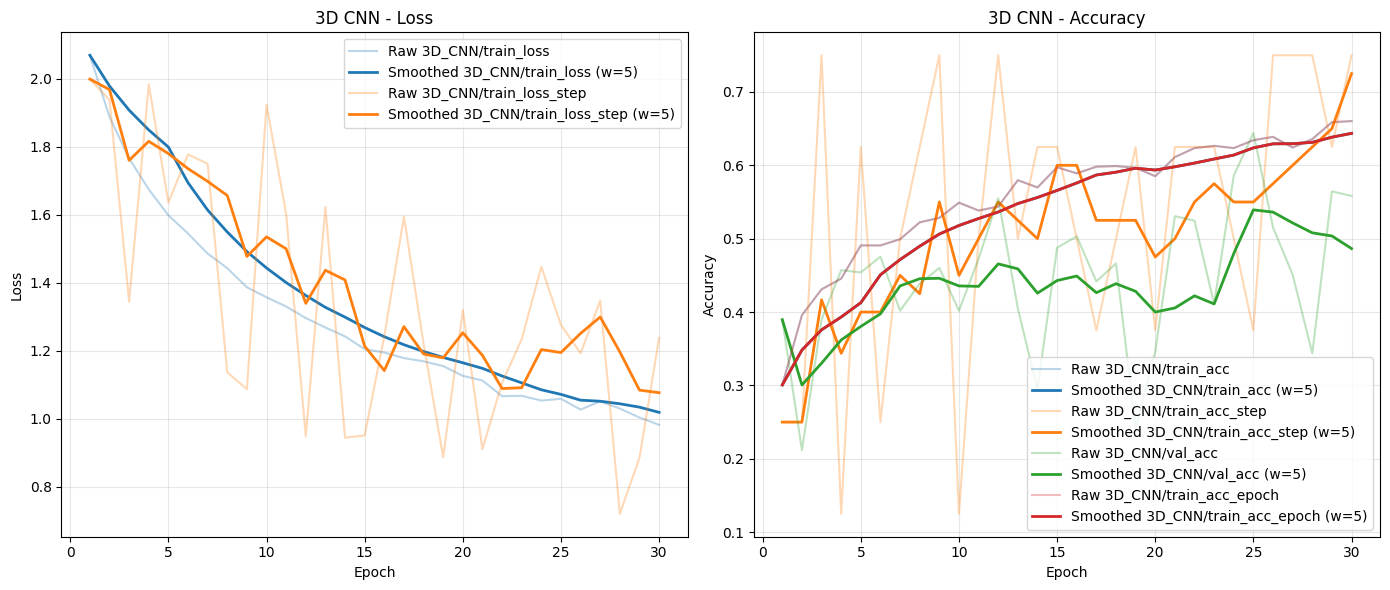

3D_CNN/train_acc_epoch,▁▃▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇███
3D_CNN/train_acc_step,▂▂▁▂▄▄▆▄▆▅▅▃█▆▃▅▅▄▄▆▇▆▇▇▇█▇▇▆▅▇▇▅▃▃▅█▆▇▆
3D_CNN/train_loss_epoch,█▇▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
3D_CNN/train_loss_step,█▇▇▇▆▆▄▅▄▆▅▆▃▄▆▃▃▅▅▂▃▃▂▂▂▁▂▂▂▂▂▂▄▅▄▄▁▂▂▃
3D_CNN/val_acc,▄▁▄▅▅▅▄▅▅▄▅▇▄▂▅▆▅▅▁▃▆▆▄▇█▆▅▃▇▇
epoch,▁▁▁▁▁▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇█████
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇█████
3D_CNN/train_acc_epoch,0.66028
3D_CNN/train_acc_step,0.625
3D_CNN/train_loss_epoch,0.98224
3D_CNN/train_loss_step,1.08951


In [23]:
print("\n🚀 Training 3D CNN...")
task_3d = VideoClassificationTask(model_3d, "3D_CNN")
history_3d = MetricHistoryCallback()

trainer_3d = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator="auto",
    logger=WandbLogger(project=WANDB_PROJECT, name="3D_CNN"),
    callbacks=[history_3d],
    enable_checkpointing=False
)
trainer_3d.fit(task_3d, dm)

plot_training_curves(history_3d.history, title="3D CNN")
wandb.finish()

Let's compute the confusion matrix also in this case:

📊 Generating Confusion Matrix for 3D CNN...


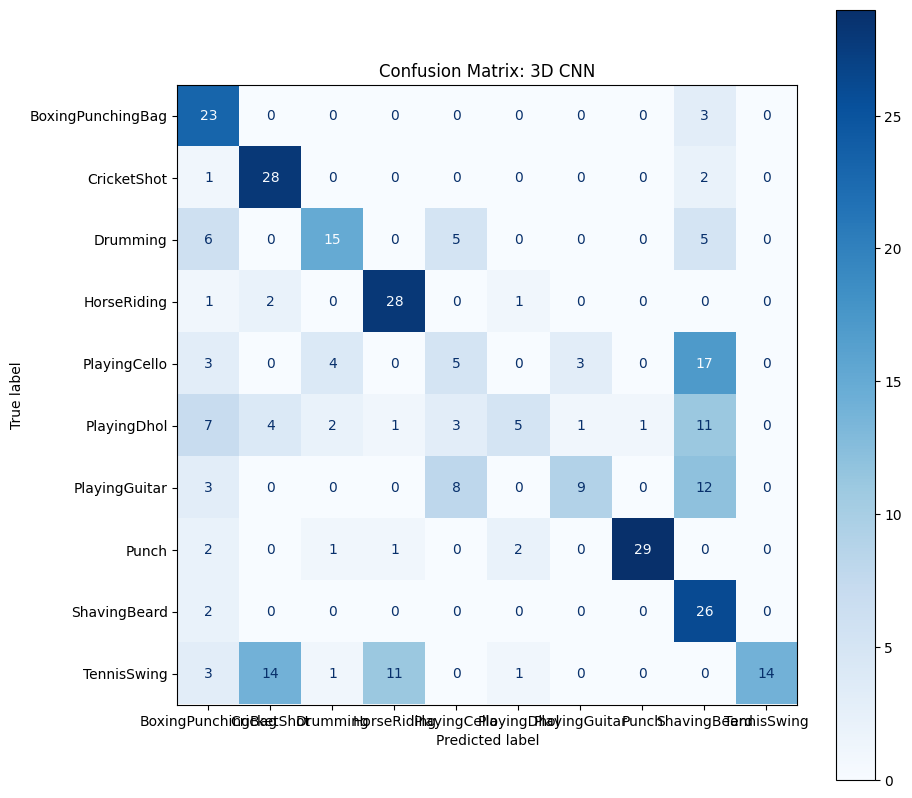

In [24]:
# Evaluate and plot for 3D CNN
print("📊 Generating Confusion Matrix for 3D CNN...")
evaluate_and_plot_confusion_matrix(task_3d, dm, "Confusion Matrix: 3D CNN")

> 📝 **Reflection 4**
>
> <i>Compare the training speed (steps/second) and the final performance between the Tiny 2D CNN baseline and your custom 3D CNN. Since they have the same parameter count, why did the 3D CNN perform better?</i>
>
> Your answer

### Part 3: Video Transformer

Let's now see a third approach, where we process videos with a transformer.

To do so, we need to turn a 5D video into a 1D sequence of tokens.

We will do so with **Tubelet Patching**, i.e., extracting non-overlapping 3D blocks (tubelets) from the video.

A mathematically elegant way to extract non-overlapping patches and project them to an embedding dimension simultaneously is using a single `Conv3d` layer where `stride == kernel_size`.

> ☑️ **TODO 3.1: Implement Tubelet Patch Embedding**

In [25]:
class TubeletPatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, embed_dim=128, tubelet_size=(4, 16, 16)):
        """
        tubelet_size format: (Time, Height, Width)
        """
        super().__init__()

        # <YOUR CODE HERE>
        # Define a Conv3d layer that extracts non-overlapping patches.
        # Kernel size AND Stride should be equal to the tubelet_size.
        
        # </YOUR CODE HERE>

    def forward(self, x):
        # x shape: (B, C, T, H, W)
        x = self.proj(x) # Output shape: (B, embed_dim, T', H', W')

        # <YOUR CODE HERE>
        # Flatten the spatial and temporal dimensions (T', H', W') into a single dimension N
        # Resulting shape should be (B, embed_dim, N)
        

        # Transpose to get sequence format for Transformers: (B, N, embed_dim)
        
        # </YOUR CODE HERE>
        return x

# Sanity check
patcher = TubeletPatchEmbedding().to(device)
patched_out = patcher(dummy_batch)
print(f"Patched Video Shape: {patched_out.shape} -> (Batch, Num_Tokens, Embed_Dim)")

Patched Video Shape: torch.Size([16, 64, 128]) -> (Batch, Num_Tokens, Embed_Dim)


> 📝 **Reflection 5**
>
> <i>If our input video is $16 \times 64 \times 64$ ($T \times H \times W$) and our tubelet size is $4 \times 16 \times 16$, how many tokens $N$ will be generated per video? Verify your math with the output shape printed by the sanity check above.</i>
>
> Your answer

> 📝 **Reflection 6**
>
> <i>How does the conv3d layer divide the input into patches and compute embeddings at the same time?</i>
>
> Your answer

Now we will construct the actual Video Vision Transformer using our Tubelet Patcher.



> ☑️ **TODO 3.2: Build the Video Transformer & Add Positional Embeddings**
>
> Transformers have no inherent sense of space or time; they are permutation invariant.
> You must add a positional embedding to your tokens before they enter the transformer layers
> so the model knows "when" and "where" each tubelet came from.
>
> We will use **learnable embeddings** (a randomly initialized `nn.Parameter` that updates during training).

In [26]:
class VideoTransformer(nn.Module):
    def __init__(self, embed_dim=128, num_classes=NUM_CLASSES,
                 frames=FRAMES, img_size=IMG_SIZE, tubelet_size=(4, 16, 16)):
        super().__init__()
        self.patch_embed = TubeletPatchEmbedding(embed_dim=embed_dim, tubelet_size=tubelet_size)

        # Calculate the total number of patches (N)
        num_patches = (frames // tubelet_size[0]) * \
                      (img_size // tubelet_size[1]) * \
                      (img_size // tubelet_size[2])

        # <YOUR CODE HERE>
        # Define a learnable positional embedding parameter of shape (1, num_patches, embed_dim)
        
        # </YOUR CODE HERE>

        # Define the Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=256,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # Classification Head
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # 1. Extract Patches: (B, C, T, H, W) -> (B, N, embed_dim)
        x = self.patch_embed(x)

        # <YOUR CODE HERE>
        # 2. Inject spatial-temporal context by adding the positional embeddings
        
        # </YOUR CODE HERE>

        # 3. Pass through Transformer
        x = self.transformer(x)

        # 4. Global Average Pooling over the sequence dimension N
        x = x.mean(dim=1)

        # 5. Classify
        return self.head(x)

# Sanity check
model_vit = VideoTransformer().to(device)
dummy_out = model_vit(dummy_batch)
print(f"ViT Model Output Shape: {dummy_out.shape} (Expected: {BATCH_SIZE}, {NUM_CLASSES})")

ViT Model Output Shape: torch.Size([16, 10]) (Expected: 16, 10)


### 3.1 Training the Video Transformer
Let's train the Transformer. Watch how its loss curve converges compared to the CNNs.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



🚀 Training Video Transformer...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VideoTransformer   │  667 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 667 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 667 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 28                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


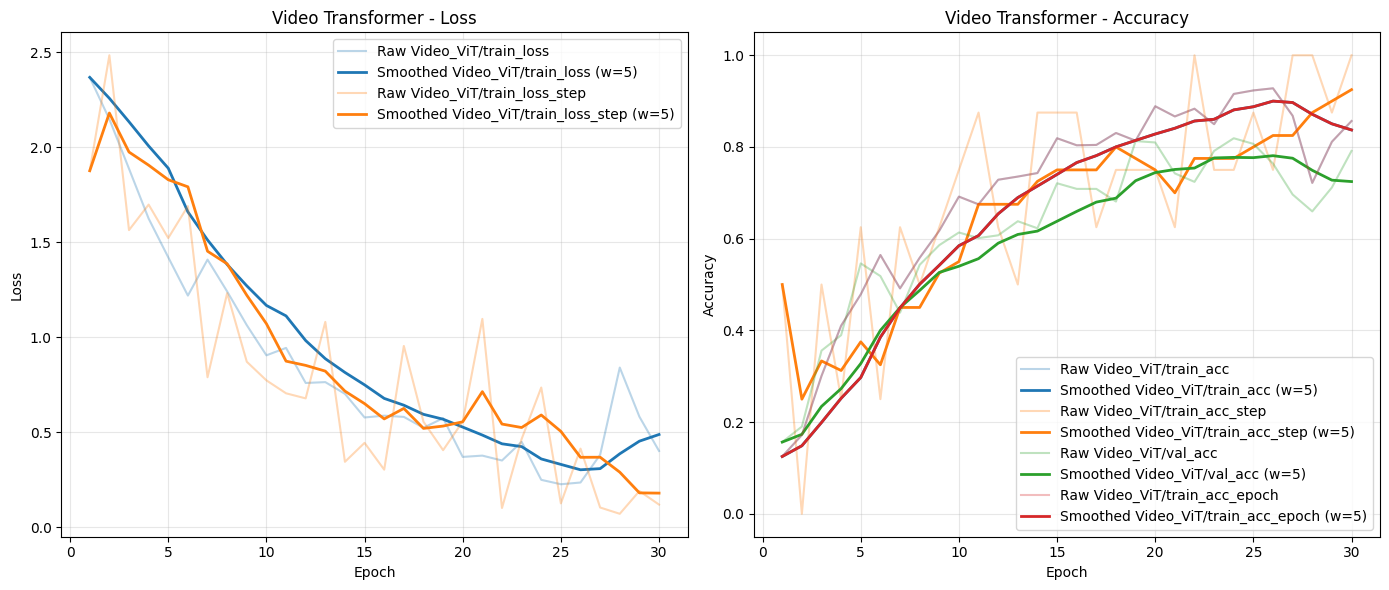

Video_ViT/train_acc_epoch,▁▁▃▃▄▅▄▅▅▆▆▆▆▆▇▇▇▇▇█▇█▇███▇▆▇▇
Video_ViT/train_acc_step,▁▁▁▄▅▃▅▅▃▃▆▆▆▃▅█▄▅▅█▇▆▇▅▆▇▇▇█▇▇▇▇▇▅▇▇▆▅▇
Video_ViT/train_loss_epoch,█▇▆▆▅▄▅▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▂▁▁▁▂▃▂▂
Video_ViT/train_loss_step,██▇▆▅▅▅▄▆▅▃▄▃▅▄▂▅▃▄▁▃▂▂▃▃▂▁▁▁▂▂▁▁▁▄▂▃▃▃▂
Video_ViT/val_acc,▁▁▃▃▅▅▄▅▆▆▆▆▆▆▇▇▇▇██▇▇███▇▇▆▇█
epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇████
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█████
Video_ViT/train_acc_epoch,0.8566
Video_ViT/train_acc_step,0.8125
Video_ViT/train_loss_epoch,0.40208
Video_ViT/train_loss_step,0.35977


In [27]:
print("\n🚀 Training Video Transformer...")
task_vit = VideoClassificationTask(model_vit, "Video_ViT")
history_vit = MetricHistoryCallback()

trainer_vit = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator="auto",
    logger=WandbLogger(project=WANDB_PROJECT, name="Video_ViT"),
    callbacks=[history_vit],
    enable_checkpointing=False
)
trainer_vit.fit(task_vit, dm)

plot_training_curves(history_vit.history, title="Video Transformer")
wandb.finish()

Let's plot the confusion matrix:

📊 Generating Confusion Matrix for Video Transformer...


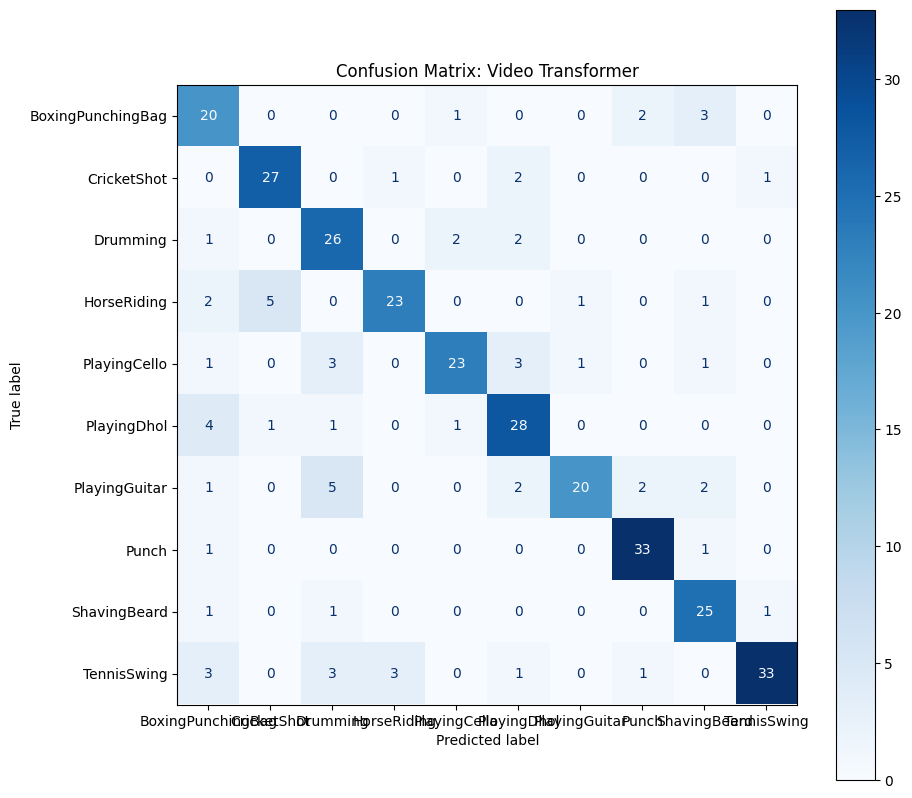

In [28]:
# Evaluate and plot for Video Transformer
print("📊 Generating Confusion Matrix for Video Transformer...")
evaluate_and_plot_confusion_matrix(task_vit, dm, "Confusion Matrix: Video Transformer")

> 📝 **Reflection 7**
>
> <i>Compare the results obtained in the different training runs and summarize them below. What is happening? Which approach (Tiny 2D Late Fusion vs. 3D CNN vs. Video ViT) makes more sense for a dataset where motion defines the class? How does the "Tubelet" strategy of the Vision Transformer offer a middle ground between spatial-only processing and heavy 3D convolutions?</i>
>
> Your text

## 🚀 Part 4: Extensions and Homeworks

Now that you have implemented the core data management techniques for 2D, 3D, and Transformer architectures, it is time to synthesize your findings.

### 📝 1. Implement Two-Stream Architecture (Homework)
While 3D CNNs learn motion implicitly, Two-Stream networks provide motion explicitly.



* **Task:** Extend the 2D Baselines to support a Two-Stream approach.
* **The Challenge:** You will need to write a pre-processing function that calculates Dense Optical Flow between consecutive frames, and feed the resulting flow fields into a second CNN branch, averaging the final logits.
* **Comparison:** How does the explicit Optical Flow stream compare to the 3D CNN in terms of capturing temporal dynamics?

### 🧪 2. Temporal Stride Ablation
Video data is highly redundant. Consecutive frames often look identical.
* **Task:** Modify the `InMemoryUCFDataModule` to sample every *n*-th frame instead of evenly spaced frames (Temporal Striding).
* **Experiment:** Try a temporal stride of 2 and 4. Train the `Video3DCNN`.
* **Question:** How does skipping frames affect the model's ability to learn? Does the increased "temporal receptive field" help or hurt?

---
**Submission:**
Please wrap up your code, ensure your WandB logs are synced (include the link in your notebook), and submit your `.ipynb` file via email.